
# Tutorial Session 3: Regression Interpretation and Evaluation

This tutorial continues the regression workflow from the previous programming session.

## Topics covered
1. Ordinary Least Squares (OLS) using the matrix formula
2. Predictions and residuals
3. Residual Sum of Squares (RSS)
4. Full-column-rank check
5. Hat matrix and projection
6. TSS, MSS and RSS decomposition
7. Coefficient of determination $R^2$
8. Estimation of noise variance $\hat{\sigma}^2$
9. Standard errors of regression coefficients
10. Interpreting p-values
11. Simple linear regression case study
12. Multiple linear regression
13. Correlation analysis
14. Final integrated exercise

> **How to use this notebook:**  
> If you run it after Tutorial 2 and already have a suitable DataFrame in memory, the notebook will try to reuse it. Otherwise, it creates a small Advertising-style dataset so every cell still runs.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## 2. Reuse the dataset from Tutorial 2

The lecture case study uses the variables:

- `TV`
- `Radio`
- `Newspaper`
- `Sales`

The next cell creates a small fallback Advertising-style dataset for demonstration.


In [2]:
## Create the dataset for Tutorial 3
reg_df = pd.DataFrame(
    {
        "TV": [
            44.5, 17.2, 151.5, 180.8, 8.7,
            57.5, 120.2, 214.7, 23.8, 97.5,
            240.1, 66.1, 199.8, 28.6, 144.4,
            88.0, 265.6, 109.8, 39.6, 175.1,
        ],
        "Radio": [
            39.3, 45.9, 41.3, 10.8, 48.9,
            32.8, 19.6, 24.0, 35.1, 7.6,
            16.7, 5.8, 2.6, 18.4, 12.5,
            25.1, 20.0, 14.3, 28.5, 34.2,
        ],
        "Newspaper": [
            45.1, 69.3, 58.5, 58.4, 75.0,
            23.5, 11.6, 4.0, 65.9, 7.2,
            22.9, 24.2, 21.2, 10.6, 31.5,
            19.7, 17.8, 12.3, 38.6, 18.9,
        ],
        "Sales": [
            10.4, 5.9, 18.5, 17.9, 4.8,
            11.8, 13.2, 17.4, 7.2, 11.7,
            20.1, 8.6, 18.2, 7.0, 14.6,
            12.1, 21.5, 13.0, 9.2, 18.1,
        ],
    }
)

reg_df.head()

,TV,Radio,Newspaper,Sales
0,44.5000,39.3000,45.1000,10.4000
1,17.2000,45.9000,69.3000,5.9000
2,151.5000,41.3000,58.5000,18.5000
3,180.8000,10.8000,58.4000,17.9000
4,8.7000,48.9000,75.0000,4.8000


In [3]:
print("Shape:", reg_df.shape)
print("\nColumns:", list(reg_df.columns))
print("\nSummary:")
display(reg_df.describe())

Shape: (20, 4)

Columns: ['TV', 'Radio', 'Newspaper', 'Sales']

Summary:


,TV,Radio,Newspaper,Sales
count,20.0000,20.0000,20.0000,20.0000
mean,113.6750,24.1700,31.8100,13.0600
std,79.3572,13.6446,22.3862,5.0453
min,8.7000,2.6000,4.0000,4.8000
25%,43.2750,13.8500,16.4250,9.0500
50%,103.6500,22.0000,23.2000,12.5500
75%,176.5250,34.4250,48.4250,17.9500
max,265.6000,48.9000,75.0000,21.5000



## 3. Simple Linear Regression: TV $\rightarrow$ Sales

We first model Sales using only TV advertising:

$$
Sales_i = \beta_0 + \beta_1 TV_i + \epsilon_i
$$

To use the matrix form of OLS, we construct

$$
X =
\begin{bmatrix}
1 & TV_1 \\
1 & TV_2 \\
\vdots & \vdots \\
1 & TV_n
\end{bmatrix},
\qquad
Y =
\begin{bmatrix}
Sales_1\\
Sales_2\\
\vdots\\
Sales_n
\end{bmatrix}
$$


In [4]:
x = reg_df["TV"].to_numpy()
y = reg_df["Sales"].to_numpy()

X = np.column_stack([np.ones(len(x)), x])
Y = y.reshape(-1, 1)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("\nFirst 5 rows of X:")
print(X[:5])

X shape: (20, 2)
Y shape: (20, 1)

First 5 rows of X:
[[  1.   44.5]
 [  1.   17.2]
 [  1.  151.5]
 [  1.  180.8]
 [  1.    8.7]]



## 4. Closed-form Ordinary Least Squares

The OLS estimator is $\hat{\beta} = (X^TX)^{-1}X^TY$

For simple regression, $\hat{\beta} =
\begin{bmatrix}
\hat{\beta}_0\\
\hat{\beta}_1
\end{bmatrix}
$


In [5]:
XtX = X.T @ X
XtY = X.T @ Y

beta_hat = np.linalg.inv(XtX) @ XtY

print("X^T X =")
print(XtX)

print("\nX^T Y =")
print(XtY)

print("\nEstimated coefficients =")
print(beta_hat)

beta0 = float(beta_hat[0, 0])
beta1 = float(beta_hat[1, 0])

print(f"\nFitted model: Sales_hat = {beta0:.4f} + {beta1:.4f} * TV")

X^T X =
[[    20.     2273.5 ]
 [  2273.5  378093.89]]

X^T Y =
[[  261.2 ]
 [37033.64]]

Estimated coefficients =
[[6.0851]
 [0.0614]]

Fitted model: Sales_hat = 6.0851 + 0.0614 * TV


### Check the result using a regression library

In [6]:
sk_model = LinearRegression()
sk_model.fit(reg_df[["TV"]], y)

print("Manual OLS intercept :", beta0)
print("sklearn intercept     :", sk_model.intercept_)
print("Manual OLS slope      :", beta1)
print("sklearn slope         :", sk_model.coef_[0])

Manual OLS intercept : 6.085116505410787
sklearn intercept     : 6.085116505410789
Manual OLS slope      : 0.06135811299396714
sklearn slope         : 0.061358112993967096



## 5. Predictions and Residuals

Predicted values are $\hat{Y}=X\hat{\beta}$

Residuals are $e=Y-\hat{Y}$

A positive residual means the observed value is above the fitted regression prediction.  
A negative residual means the observed value is below the fitted prediction.


In [7]:
Y_hat = X @ beta_hat
residuals = Y - Y_hat

results_simple = reg_df[["TV", "Sales"]].copy()
results_simple["Predicted_Sales"] = Y_hat.ravel()
results_simple["Residual"] = residuals.ravel()

display(results_simple.head(10))

,TV,Sales,Predicted_Sales,Residual
0,44.5000,10.4000,8.8156,1.5844
1,17.2000,5.9000,7.1405,-1.2405
2,151.5000,18.5000,15.3809,3.1191
3,180.8000,17.9000,17.1787,0.7213
4,8.7000,4.8000,6.6189,-1.8189
5,57.5000,11.8000,9.6132,2.1868
6,120.2000,13.2000,13.4604,-0.2604
7,214.7000,17.4000,19.2587,-1.8587
8,23.8000,7.2000,7.5454,-0.3454
9,97.5000,11.7000,12.0675,-0.3675



### Residual Sum of Squares

$
RSS = \sum_{i=1}^{n}(y_i-\hat y_i)^2
$


In [8]:
RSS = float(np.sum(residuals**2))
print(f"RSS = {RSS:.6f}")

RSS = 33.173301


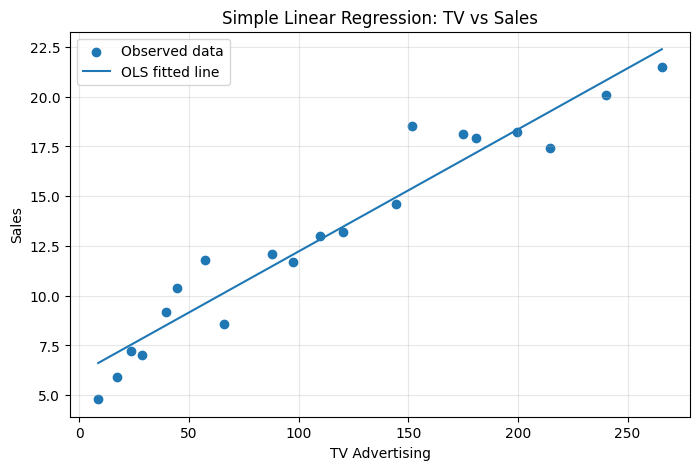

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(reg_df["TV"], reg_df["Sales"], label="Observed data")
order = np.argsort(reg_df["TV"].to_numpy())
plt.plot(reg_df["TV"].to_numpy()[order], Y_hat.ravel()[order], label="OLS fitted line")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("Simple Linear Regression: TV vs Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 6. Full Column Rank

The formula $(X^TX)^{-1}$ requires the columns of $X$ to be linearly independent.

If one predictor is an exact linear combination of another predictor, $X$ loses full column rank and $X^TX$ becomes singular.


In [10]:
X_rank_demo = np.column_stack(
    [np.ones(5), np.array([1, 2, 3, 4, 5]), 2 * np.array([1, 2, 3, 4, 5])]
)

print("Matrix X:")
print(X_rank_demo)

print("\nRank of X:", np.linalg.matrix_rank(X_rank_demo))
print("Number of columns:", X_rank_demo.shape[1])

XtX_rank_demo = X_rank_demo.T @ X_rank_demo
print("\nX^T X:")
print(XtX_rank_demo)

try:
    np.linalg.inv(XtX_rank_demo)
except np.linalg.LinAlgError as e:
    print("\nInverse failed:", e)

Matrix X:
[[ 1.  1.  2.]
 [ 1.  2.  4.]
 [ 1.  3.  6.]
 [ 1.  4.  8.]
 [ 1.  5. 10.]]

Rank of X: 2
Number of columns: 3

X^T X:
[[  5.  15.  30.]
 [ 15.  55. 110.]
 [ 30. 110. 220.]]

Inverse failed: Singular matrix



## 7. Hat Matrix

The hat matrix is $H=X(X^TX)^{-1}X^T$ and it maps the observed response vector to the fitted response $\hat{Y}=HY$

We can verify that this gives the same prediction as $X\hat{\beta}$.



A key OLS property is that the residual vector is orthogonal to every column of $X$: $X^Te=0$

In [11]:
orthogonality_check = X.T @ residuals
print("X^T e =")
print(orthogonality_check)

X^T e =
[[-0.]
 [-0.]]



## 8. Evaluating the Regression Fit: TSS, MSS and RSS

Define:

$
TSS = \sum_{i=1}^{n}(y_i-\bar y)^2
$

$
MSS = \sum_{i=1}^{n}(\hat y_i-\bar y)^2
$

$
RSS = \sum_{i=1}^{n}(y_i-\hat y_i)^2
$

For an OLS model with an intercept, $TSS=MSS+RSS$


In [12]:
y_bar = np.mean(y)

TSS = np.sum((y - y_bar) ** 2)
MSS = np.sum((Y_hat.ravel() - y_bar) ** 2)
RSS_check = np.sum((y - Y_hat.ravel()) ** 2)

print(f"Mean Sales = {y_bar:.6f}")
print(f"TSS        = {TSS:.6f}")
print(f"MSS        = {MSS:.6f}")
print(f"RSS        = {RSS_check:.6f}")
print(f"MSS + RSS  = {(MSS + RSS_check):.6f}")
print(f"TSS == MSS + RSS ? {np.isclose(TSS, MSS + RSS_check)}")

Mean Sales = 13.060000
TSS        = 483.648000
MSS        = 450.474699
RSS        = 33.173301
MSS + RSS  = 483.648000
TSS == MSS + RSS ? True



## 9. Coefficient of Determination $R^2$

$
R^2 = \frac{MSS}{TSS}
=1-\frac{RSS}{TSS}$

$R^2$ measures the fraction of variation in the response explained by the fitted regression model.


In [13]:
R2_manual = 1 - RSS_check / TSS
R2_sklearn = r2_score(y, Y_hat.ravel())

print(f"Manual R^2  = {R2_manual:.6f}")
print(f"sklearn R^2 = {R2_sklearn:.6f}")

Manual R^2  = 0.931410
sklearn R^2 = 0.931410



## 10. Estimate the Noise Variance

For a model with $p$ predictors plus an intercept, $
\hat{\sigma}^2 =
\frac{RSS}{n-(p+1)}
$

For the simple regression here, $p=1$.


In [14]:
n = len(y)
p = 1

sigma2_hat = RSS_check / (n - (p + 1))
sigma_hat = np.sqrt(sigma2_hat)

print(f"n = {n}")
print(f"p = {p}")
print(f"Estimated sigma^2 = {sigma2_hat:.6f}")
print(f"Estimated sigma   = {sigma_hat:.6f}")

n = 20
p = 1
Estimated sigma^2 = 1.842961
Estimated sigma   = 1.357557



## 11. Standard Errors of the Regression Coefficients

For OLS, $\mathrm{Cov}(\hat{\beta}) =\hat{\sigma}^2(X^TX)^{-1}$

The standard error of each coefficient is the square root of the corresponding diagonal entry.


In [15]:
cov_beta = sigma2_hat * np.linalg.inv(X.T @ X)
standard_errors = np.sqrt(np.diag(cov_beta))

print("Estimated covariance matrix of beta_hat:")
print(cov_beta)

print("\nStandard errors:")
print(f"SE(intercept) = {standard_errors[0]:.6f}")
print(f"SE(TV)        = {standard_errors[1]:.6f}")

Estimated covariance matrix of beta_hat:
[[ 0.2912 -0.0018]
 [-0.0018  0.    ]]

Standard errors:
SE(intercept) = 0.539610
SE(TV)        = 0.003925



## 12. Regression Summary and p-values

The lecture case study reports, for each coefficient:

- coefficient estimate
- standard error
- test statistic
- p-value

A small p-value provides evidence against the null hypothesis that the corresponding true coefficient equals zero.


In [ ]:
import statsmodels.api as sm

X_sm_simple = sm.add_constant(reg_df[["TV"]])
sm_simple = sm.OLS(reg_df["Sales"], X_sm_simple).fit()

print(sm_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     244.4
Date:                Sat, 05 Sep 2026   Prob (F-statistic):           6.43e-12
Time:                        00:51:02   Log-Likelihood:                -33.439
No. Observations:                  20   AIC:                             70.88
Df Residuals:                      18   BIC:                             72.87
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.0851      0.540     11.277      0.0

In [17]:
simple_inference = pd.DataFrame(
    {
        "Coefficient": sm_simple.params,
        "Std_Error": sm_simple.bse,
        "t_statistic": sm_simple.tvalues,
        "p_value": sm_simple.pvalues,
    }
)

display(simple_inference)

,Coefficient,Std_Error,t_statistic,p_value
const,6.0851,0.5396,11.2769,0.0000
TV,0.0614,0.0039,15.6343,0.0000



### Interpretation task

Using a significance level of $\alpha=0.05$:

1. Look at the p-value for TV.
2. Decide whether there is statistical evidence that TV advertising is associated with Sales.
3. Compare the coefficient with its standard error.



## 13. Multiple Linear Regression

Now use all three advertising predictors:

$$
Sales
=
\beta_0
+
\beta_1TV
+
\beta_2Radio
+
\beta_3Newspaper
+
\epsilon
$$

In multiple regression, the coefficient of one predictor is interpreted **while holding the other predictors fixed**.


In [18]:
X_multi_raw = reg_df[["TV", "Radio", "Newspaper"]]
y_multi = reg_df["Sales"]

X_multi_sm = sm.add_constant(X_multi_raw)
multi_model = sm.OLS(y_multi, X_multi_sm).fit()

print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                     78.63
Date:                Sat, 05 Sep 2026   Prob (F-statistic):           8.59e-10
Time:                        00:51:02   Log-Likelihood:                -32.671
No. Observations:                  20   AIC:                             73.34
Df Residuals:                      16   BIC:                             77.32
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1529      1.064      4.843      0.0

In [19]:
multi_results = pd.DataFrame(
    {
        "Coefficient": multi_model.params,
        "Std_Error": multi_model.bse,
        "t_statistic": multi_model.tvalues,
        "p_value": multi_model.pvalues,
    }
)

display(multi_results)

,Coefficient,Std_Error,t_statistic,p_value
const,5.1529,1.0639,4.8435,0.0002
TV,0.0635,0.0046,13.8484,0.0000
Radio,0.0317,0.0313,1.0117,0.3267
Newspaper,-0.0025,0.0188,-0.1346,0.8946



### Evaluate the multiple regression fit


In [20]:
y_hat_multi = multi_model.predict(X_multi_sm)
resid_multi = y_multi.to_numpy() - y_hat_multi.to_numpy()

RSS_multi = np.sum(resid_multi**2)
TSS_multi = np.sum((y_multi - y_multi.mean()) ** 2)
R2_multi = 1 - RSS_multi / TSS_multi

print(f"RSS (multiple regression) = {RSS_multi:.6f}")
print(f"TSS                       = {TSS_multi:.6f}")
print(f"R^2                       = {R2_multi:.6f}")
print(f"statsmodels R^2           = {multi_model.rsquared:.6f}")

RSS (multiple regression) = 30.720018
TSS                       = 483.648000
R^2                       = 0.936483
statsmodels R^2           = 0.936483



### Interpretation task

For each predictor:

- identify the sign of the coefficient;
- identify whether the p-value is small or large;
- interpret the coefficient while holding the other predictors fixed.

Pay special attention to whether a predictor that looks related to Sales by itself remains important after TV and Radio are included together.



## 14. Correlation Analysis

The lecture case study compares the regression results with correlations among

- TV
- Radio
- Newspaper
- Sales.

Correlation describes pairwise linear association. Multiple regression estimates the association of one predictor with the response while controlling for the other predictors.


In [21]:
corr_matrix = reg_df[["TV", "Radio", "Newspaper", "Sales"]].corr()
display(corr_matrix)

,TV,Radio,Newspaper,Sales
TV,1.0000,-0.4547,-0.4248,0.9651
Radio,-0.4547,1.0000,0.6362,-0.3758
Newspaper,-0.4248,0.6362,1.0000,-0.3812
Sales,0.9651,-0.3758,-0.3812,1.0000


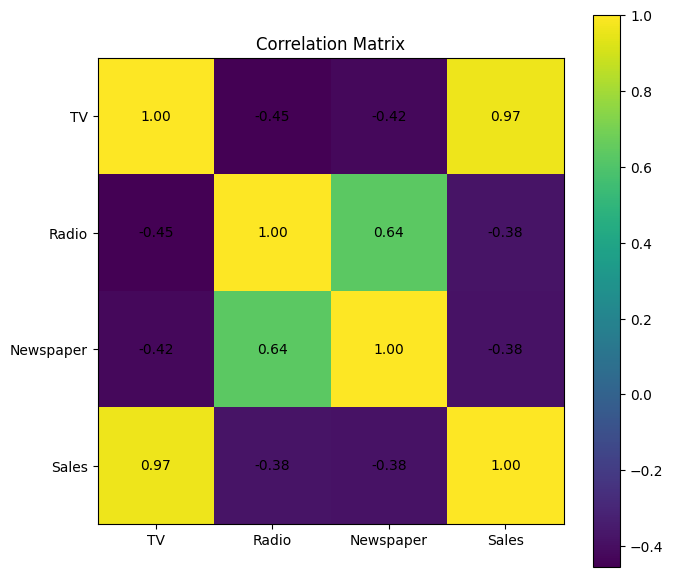

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(corr_matrix.to_numpy())

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.index)

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Matrix")
plt.colorbar(im)
plt.tight_layout()
plt.show()


## 15. Compare Simple Regressions with Multiple Regression

Fit three separate simple regression models:

1. Sales on TV
2. Sales on Radio
3. Sales on Newspaper

Then compare their coefficients and p-values with the multiple regression model.


In [23]:
comparison_rows = []

for predictor in ["TV", "Radio", "Newspaper"]:
    X_one = sm.add_constant(reg_df[[predictor]])
    model_one = sm.OLS(reg_df["Sales"], X_one).fit()

    comparison_rows.append(
        {
            "Predictor": predictor,
            "Simple_Coefficient": model_one.params[predictor],
            "Simple_p_value": model_one.pvalues[predictor],
            "Multiple_Coefficient": multi_model.params[predictor],
            "Multiple_p_value": multi_model.pvalues[predictor],
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,Predictor,Simple_Coefficient,Simple_p_value,Multiple_Coefficient,Multiple_p_value
0,TV,0.0614,0.0000,0.0635,0.0000
1,Radio,-0.1390,0.1025,0.0317,0.3267
2,Newspaper,-0.0859,0.0973,-0.0025,0.8946



### Discussion

- Does a predictor's coefficient change after other predictors are added?
- Does its p-value change?
- Why can pairwise correlation and multiple-regression significance tell different stories?



## 16. Prediction from the Multiple Regression Model

Use the fitted model to predict Sales for a new advertising plan.


In [24]:
new_campaign = pd.DataFrame({"TV": [150], "Radio": [20], "Newspaper": [30]})

new_campaign_sm = sm.add_constant(new_campaign, has_constant="add")
predicted_sales = multi_model.predict(new_campaign_sm)

print("New campaign:")
display(new_campaign)

print(f"Predicted Sales = {predicted_sales.iloc[0]:.4f}")

New campaign:


,TV,Radio,Newspaper
0,150,20,30


Predicted Sales = 15.2403



# Final Exercise

A company is deciding how to allocate its advertising budget. Using the regression results from this tutorial, answer the following questions.

### Task A - Choosing an Advertising Strategy

The company can increase its TV advertising budget by 20 units, while keeping Radio and Newspaper spending unchanged.

1. Based on the multiple regression coefficient for TV, approximately how much would the predicted Sales change?

2. Would you recommend increasing TV advertising based only on the statistical evidence from the model? Explain your answer using the p-value.

### Task B - A Surprising Result

Radio has a negative correlation with Sales, but its coefficient in the multiple regression model is positive.

1. What does the negative correlation suggest when Radio is considered by itself?

2. What does the positive multiple-regression coefficient suggest after accounting for TV and Newspaper?

3. In 2-3 sentences, explain why these two results can be different.

### Task C - Make a Decision

A manager says:

> "Newspaper advertising has a negative coefficient, so we should stop spending money on Newspaper."

Do you agree with this conclusion?

Give a short statistical justification using the coefficient and p-value.

In [25]:
# Write your solution here